<a href="https://colab.research.google.com/github/AdamHopkinss/DD2365/blob/main/Current_Modular_Euler_equations_compressible_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Euler equations for compressible flow**
**Johan Hoffman**

# **Abstract**

This short report show an example on how to use FEniCS to solve the Euler equations using FEM, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://www.kth.se/social/course/DD2365/)

# **About the code**

In [1]:
# This program is an example file for the course
# DD2365 Advanced Computation in Fluid Mechanics,
# KTH Royal Institute of Technology, Stockholm, Sweden,

# Copyright (C) 2021 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License v2.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

# **Set up environment**

In [2]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt
import matplotlib.ticker as ticker

# **Introduction**


The Euler equations take the form

$
\begin{eqnarray}
\dot \rho + \nabla \cdot (u \rho) = 0, \\
\dot m + \nabla \cdot (u m) + \nabla p = f, \\
\dot E + \nabla \cdot (u E) + \nabla \cdot(up)= 0,
\end{eqnarray}
$

together with suitable initial and boundary conditions.

Here velocity is given by

$u = \frac{m}{\rho},$

and for a perfect gas, the pressure is given by

$p = (\gamma - 1)(E-\rho\frac{\vert u\vert^2}{2}),$

where $\gamma = 1.4$ is the specific heat ratio for air, and we get the temperature,

$T = \frac{E}{\rho} - \frac{\vert u\vert^2}{2},$

the speed of sound,

$c =\sqrt{\gamma(\gamma-1)T},$

and the Mach number,

$M = \frac{\vert u\vert }{c}.$

Here we present a FEniCS implementation of a stabilized finite element method to solve the Euler equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

### Dimensionless form

Define reference quantaties (e.g. inflow):
* $\rho_0$: inflow density  
* $u_0$: inflow velocity  
* $p_0$: inflow pressure  
* $E_0$: inflow energy  
* $T_0$: inflow temperature  
* $L$: characteristic length (e.g. meteor diameter)

We now define our variables on dimensionless form:
\begin{align*}
  \tilde{\rho} = \frac{\rho}{\rho_\infty}, \quad \tilde{u} = \frac{u}{u_\infty}, \quad \tilde{p} = \frac{p}{p_\infty}, \quad \tilde{E} = \frac{E}{E_\infty} \\
  \tilde{m} = \frac{m}{\rho_\infty u_\infty}, \quad \tilde{x} = \frac{x}{L}, \quad \tilde{t} = \frac{t}{L/u_\infty}
\end{align*}

With this we move to rewrite the Euler equations on dimensionless form:

Density:
\begin{align*}
  \partial_t \rho + \nabla_x \cdot (\rho u) = 0 \\
  \frac{u_\infty \rho_\infty}{L}\left(\partial_{\tilde{t}} \tilde{\rho} + \nabla_{\tilde{x}}(\tilde{\rho} \tilde{u})\right) = 0 \\
  \Rightarrow \boxed{\partial_{\tilde{t}} \tilde{\rho} + \nabla_{\tilde{x}}(\tilde{\rho} \tilde{u}) = 0}
\end{align*}

Momentum:
\begin{align*}
  \partial_t m + \nabla_x \cdot (u m) + \nabla_x p = f \\
  \frac{\rho_\infty u_\infty^2}{L} \left( \partial_{\tilde{t}} \tilde{m} + \nabla_{\tilde{x}} (\tilde{u} \tilde{m}) \right) + \frac{p_\infty}{L} \nabla_{\tilde{x}} \tilde{p} = f
\end{align*}
Letting $p_\infty = \rho_\infty u_\infty^2$ we get the dimensionless form:
$$
  \boxed{\partial_{\tilde{t}} \tilde{m} + \nabla_{\tilde{x}} (\tilde{u} \tilde{m}) + \nabla_{\tilde{x}} \tilde{p} = f^*}
$$
where $f = \frac{\rho_\infty u_\infty^2}{L} f^*$.

Energy:
\begin{align*}
  \partial_t E + \nabla \cdot ((E + p) u) = 0 \\
  \frac{E_\infty u_\infty}{L} \partial_{\tilde{t}} \tilde{E} + \frac{u_\infty}{L} \nabla_{\tilde{x}} \cdot ((E_\infty \tilde{E} + p_\infty \tilde{p}) \tilde{u}) = 0
\end{align*}
Letting $E_\infty = p_\infty = \rho_\infty u_\infty^2$, we get the dimensionless form:
$$
  \boxed{\partial_{\tilde{t}} \tilde{E} + \nabla_{\tilde{x}} \cdot \left((\tilde{E} + \tilde{p}) \tilde{u} \right) = 0}
$$

Where:
* $\tilde{p} = (\gamma - 1) \left(\tilde{E} - \tilde{\rho} \frac{|\tilde{u}|^2}{2}\right)$  
* $\tilde{T} = 2\frac{\tilde{E}}{\tilde{\rho}} -|\tilde{u}|^2$  (from using $T_\infty = \frac{u_\infty^2}{2c_v}$)

Where we assume $c_v = 718$ J/(Kg K)
We also define:

$$
  c_\infty = \sqrt{\frac{p_\infty}{\rho_\infty}}= u_\infty
$$

Which leads to

$$
  \tilde c = \sqrt{\gamma \frac{\tilde p}{\tilde \rho}}
$$

And
$$
  \tilde M = \frac{|\tilde u|}{\tilde c} \quad \text{with }\quad M_\infty = 1
$$

With this formulation, the inflow conditions in dimensionless form are:
\begin{align*}
  \tilde{\rho}_0 &= \frac{\rho_0}{\rho_\infty}, \\
  \tilde{u}_0 &= \frac{u_0}{u_\infty}, \\
  \tilde{E}_0 &= \frac{E_0}{E_\infty}, \quad \text{where } E_\infty = \rho_\infty u_\infty^2
\end{align*}

In particular, if we choose $\rho_\infty = \rho_0$, $u_\infty = u_0$, then:
$$
\tilde{\rho}_0 = 1, \quad \tilde{u}_0 = 1, \quad \tilde{E}_0 = \frac{E_0}{\rho_0 u_0^2}
$$

Using the perfect gas law:
\begin{align*}
E_0 = \frac{p_0}{\gamma - 1} + \frac{1}{2} \rho_0 u_0^2
\quad \Rightarrow \quad
\tilde{E}_0 = \frac{1}{\gamma - 1} + \frac{1}{2}
\end{align*}
if $p_0 = \rho_0 u_0^2$, which it is as we chose $p_\infty = \rho_\infty u_\infty^2$.

We thus arrive at the final dimensionless Euler system:
$$
\boxed{
\begin{aligned}
\partial_{\tilde{t}} \tilde{\rho} + \nabla_{\tilde{x}} \cdot (\tilde{\rho} \tilde{u}) &= 0 \\
\partial_{\tilde{t}} \tilde{m} + \nabla_{\tilde{x}} \cdot (\tilde{u} \tilde{m}) + \nabla_{\tilde{x}} \tilde{p} &= \tilde{f} \\
\partial_{\tilde{t}} \tilde{E} + \nabla_{\tilde{x}} \cdot \left((\tilde{E} + \tilde{p}) \tilde{u} \right) &= 0
\end{aligned}
}
$$

We also have:
$$
  \tilde{dt} \leq \frac{\text{CFL} \cdot \tilde h }{\max(|\tilde u| + \tilde c)}
$$


**Method**

**Define domain and mesh**

In [3]:
from dolfin import *
import matplotlib.pyplot as plt
import numpy as np

def make_domain_and_boundaries(L=15.0, H=10.0, rc=0.9, resolution=32, refine_levels=1,
                               refinement_radius=3, plot_mesh=False):
    xc = 0.4 * L
    yc = 0.5 * H

    # Create base mesh with a circular hole
    base_geometry = Rectangle(Point(0.0, 0.0), Point(L, H)) - Circle(Point(xc, yc), rc)
    mesh = generate_mesh(base_geometry, resolution)

    # Optional local refinement near the obstacle
    for _ in range(refine_levels):
        cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
        for cell in cells(mesh):
            cell_marker[cell] = cell.midpoint().distance(Point(xc, yc)) < refinement_radius
        mesh = refine(mesh, cell_marker)

    # Define boundary subdomains
    class Left(SubDomain):
        def inside(self, x, on_boundary): return near(x[0], 0.0)

    class Right(SubDomain):
        def inside(self, x, on_boundary): return near(x[0], L)

    class Lower(SubDomain):
        def inside(self, x, on_boundary): return near(x[1], 0.0)

    class Upper(SubDomain):
        def inside(self, x, on_boundary): return near(x[1], H)

    class Object(SubDomain):
        def inside(self, x, on_boundary): return on_boundary and not (
            near(x[0], 0.0) or near(x[0], L) or near(x[1], 0.0) or near(x[1], H)
        )

    # Mark boundaries
    boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
    boundaries.set_all(0)
    Left().mark(boundaries, 1)
    Right().mark(boundaries, 2)
    Lower().mark(boundaries, 3)
    Upper().mark(boundaries, 4)
    Object().mark(boundaries, 5)

    # Define integration measure
    ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

    # Optional mesh plot
    if plot_mesh:
        plt.figure()
        plot(mesh)
        plt.title("Generated mesh with obstacle")
        plt.show()

    return mesh, boundaries, ds, rc, xc, yc


**Define finite element approximation spaces**

In [4]:
def make_function_spaces(mesh):
    # Generate finite element spaces (for density, momentum, total energy)
    R = FunctionSpace(mesh, "Lagrange", 1)
    V = VectorFunctionSpace(mesh, "Lagrange", 1)
    Q = FunctionSpace(mesh, "Lagrange", 1)

    # Define trial and test functions
    r = TrialFunction(R)    # Density
    m = TrialFunction(V)    # Momentum
    E = TrialFunction(Q)    # Energy
    d = TestFunction(R)
    v = TestFunction(V)
    q = TestFunction(Q)

    trial_fcs = [r, m, E]
    test_fcs = [d, v, q]
    return R, V, Q, trial_fcs, test_fcs

## Altitude dependent inflow parameters

In [5]:
def get_material_properties(material):
    """
    Returns material properties for the given meteor composition.

    Supported: 'iron', 'ice', 'stone'

    Returns:
        dict with keys:
            - 'density'     [kg/m³]
            - 'strength'    [Pa] (approx. fragmentation pressure threshold)
            - 'name'        (capitalized name)
    """
    materials = {
        "iron": {
            "density": 7800.0,        # typical value for iron meteorites
            "strength": 50e6,         # ~10–100 MPa range; 50 MPa as representative
        },
        "ice": {
            "density": 917.0,         # pure water ice at 0°C
            "strength": 2e6,          # ~0.1–3 MPa; 2 MPa as ref
        },
        "stone": {
            "density": 3500.0,        # Chelyabinsk-like (18 MPa) fragmentation, typical for stony meteorites (chondrites)
            "strength": 15e6,         # ~5–20 MPa; 18 MPa as for Chelyabinsk
        }
    }

    if material not in materials:
        raise ValueError(f"Unsupported material '{material}'. Choose from: {list(materials.keys())}")

    props = materials[material]
    props["name"] = material.capitalize()
    return props


### U.S. Standard Atmosphere Model (up to 85 km)

The atmospheric inflow conditions are computed using a piecewise approximation of the U.S. Standard Atmosphere 1976. Each layer is defined by a base altitude $h_b$, lapse rate $L_b$, base temperature $T_b$, and base pressure $p_b$.

**Temperature** is computed via:

$$
T(h) = T_b + L_b (h - h_b)
$$

**Pressure** is computed using the barometric formula:

- For gradient layers ($L_b \ne 0$):

$$
p(h) = p_b \left( \frac{T(h)}{T_b} \right)^{-g_0 / (R L_b)}
$$

- For isothermal layers ($L_b = 0$):

$$
p(h) = p_b \exp\left( \frac{-g_0 (h - h_b)}{R T_b} \right)
$$

**Density** is then obtained from the ideal gas law:

$$
\rho(h) = \frac{p(h)}{R T(h)}
$$

**Total energy** per unit volume at altitude $h$ and inflow velocity $u$ is:

$$
E(h, u) = \rho(h) \left( \frac{1}{2} u^2 + \frac{R T(h)}{\gamma - 1} \right)
$$

where:

- $R = 287.05 \, \text{J/(kg·K)}$ is the specific gas constant for air  
- $\gamma = 1.4$ is the specific heat ratio  
- $g_0 = 9.80665 \, \text{m/s}^2$ is standard gravity


In [6]:

# Atmospheric layers: [Altitude [m], Temperature lapse rate [K/m], Temperature [K], Pressure [Pa]]
# Based on U.S. Standard Atmosphere 1976
atmo_layers = [
    (0,     -0.0065, 288.15, 101325.0),
    (11000,  0.0,    216.65, 22632.1),
    (20000,  0.0010, 216.65, 5474.89),
    (32000,  0.0028, 228.65, 868.019),
    (47000,  0.0,    270.65, 110.906),
    (51000, -0.0028, 270.65, 66.9389),
    (71000, -0.0020, 214.65, 3.95642),
    (84852,  0.0,    186.8673, 0.3734),  # Edge of model (about 85 km)
]


def inflow_temperature(h):
    for i in range(len(atmo_layers) - 1):
        h_b, L_b, T_b, _ = atmo_layers[i]
        h_t = atmo_layers[i+1][0]
        if h >= h_b and h < h_t:
            return T_b + L_b * (h - h_b)
    # If above last layer
    return atmo_layers[-1][2]


def inflow_density_pressure(h):
    # Constants
    R_air = 287.05      # J / (kg*K)
    g0 = 9.80665    # m/s^2
    gamma = 1.4
    for i in range(len(atmo_layers) - 1):
        h_b, L_b, T_b, p_b = atmo_layers[i]
        h_t = atmo_layers[i+1][0]
        if h >= h_b and h < h_t:
            if L_b == 0.0:
                # Isothermal layer
                exponent = -g0 * (h - h_b) / (R_air * T_b)
                p = p_b * np.exp(exponent)
            else:
                # Gradient layer
                T = T_b + L_b * (h - h_b)
                exponent = -g0 / (R_air * L_b)
                p = p_b * (T / T_b) ** exponent
            rho = p / (R_air * inflow_temperature(h))
            return rho, p
    # If above last layer
    T = inflow_temperature(h)
    p = atmo_layers[-1][3] * np.exp(-g0 * (h - atmo_layers[-1][0]) / (R_air * T))
    rho = p / (R_air * T)
    return rho, p

def inflow_energy(h, v):      # Dependent on inflow velo. and altitude
    # Constants
    R_air = 287.05      # J / (kg*K)
    g0 = 9.80665    # m/s^2
    gamma = 1.4
    rho, _ = inflow_density_pressure(h)
    T = inflow_temperature(h)
    return rho * (0.5 * v**2 + R_air * T / (gamma - 1))


### Dimensionless inflow data

In [7]:
def compute_dimensionless_inflow(h, u_0, gamma=1.4):
    R_air = 287.05  # J/(kg·K)
    c_v = 718.0     # J/(kg·K)

    # Physical values from atmospheric model
    rho_0, p_0 = inflow_density_pressure(h)
    T_0 = inflow_temperature(h)
    E_0 = inflow_energy(h, u_0)

    # Reference scales
    rho_inf = rho_0
    u_inf = u_0
    E_inf = rho_inf * u_inf**2
    p_inf = rho_inf * u_inf**2
    T_inf = u_inf**2 / (2 * c_v)

    # Dimensionless quantities
    tilde_rho_0 = 1.0
    tilde_u_0 = 1.0
    tilde_E_0 = E_0 / E_inf
    tilde_p_0 = p_0 / p_inf
    tilde_T_0 = T_0 / T_inf

    return {
        "rho": tilde_rho_0,
        "u": tilde_u_0,
        "E": tilde_E_0,
        "p": tilde_p_0,
        "T": tilde_T_0,
        "rho_phys": rho_0,
        "p_phys": p_0,
        "E_phys": E_0,
        "T_phys": T_0,
        "u_phys": u_0,
        "rho_inf": rho_inf,
        "u_inf": u_inf,
        "E_inf": E_inf,
        "p_inf": p_inf,
        "T_inf": T_inf,
    }


**Define boundary conditions**

In [8]:
def make_boundary_conditions(mesh, R, V, Q, ds, inflow, altitude, L, H):

    # Define boundary subdomains
    class DirichletBoundaryLower(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and near(x[1], 0.0)

    class DirichletBoundaryUpper(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and near(x[1], H)

    class DirichletBoundaryLeft(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and near(x[0], 0.0)

    class DirichletBoundaryRight(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and near(x[0], L)

    class DirichletBoundaryObjects(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and not (
            near(x[0], 0.0) or near(x[0], L) or near(x[1], 0.0) or near(x[1], H)
        )

    # Instantiate subdomains
    dbc_lower = DirichletBoundaryLower()
    dbc_upper = DirichletBoundaryUpper()
    dbc_left = DirichletBoundaryLeft()
    dbc_right = DirichletBoundaryRight()
    dbc_objects = DirichletBoundaryObjects()

    # Dimensionless Inflow values
    inflow = compute_dimensionless_inflow(altitude, velocity_in)

    # Constants for boundary data
    r_in = Constant(inflow["rho"])                # = 1.0
    m_in = Constant(inflow["rho"] * inflow["u"])  # = 1.0
    E_in = Constant(inflow["E"])                  # = O(1)

    r_phys = inflow["rho_phys"]
    m_phys = inflow["rho_phys"] * inflow["u"]
    E_phys = inflow["E_phys"]


    print(f"Dimensionless inflow values: \n inflow density: {float(r_in):.3f}, inflow momentum: {float(m_in):.3f}, inflow energy: {float(E_in):.3f}")

    print(f"Dimensional inflow values: \n inflow density: {float(r_phys):.3f}, inflow momentum: {float(m_phys):.3f}, inflow energy: {float(E_phys):.3f}")
    u_in = inflow["u"]
    u_phys = inflow["u_phys"]

    print(f"Inflow velocity: Dimensionless: {float(u_in)}, Dimensional: {float(u_phys)}")
    # Boundary conditions
    bcr = [DirichletBC(R, r_in, dbc_left)]
    bcE = [DirichletBC(Q, E_in, dbc_left)]

    bcm = [
        DirichletBC(V.sub(0), m_in, dbc_left),    # inflow momentum x
        DirichletBC(V.sub(1), 0.0, dbc_left),     # inflow momentum y

        # Slip-wall BCs (top/bottom)
        # DirichletBC(V.sub(0), 0.0, dbc_upper),   # x-direction
        DirichletBC(V.sub(1), 0.0, dbc_upper),    # y-direction
        # DirichletBC(V.sub(0), 0.0, dbc_lower),   # x
        DirichletBC(V.sub(1), 0.0, dbc_lower),    # y

        # Uncomment for strong BC enforment on object surface
        # If so, change: + alpha * inner(dot(mm, normal), dot(v, normal)) * ds(5)
        # in variational form (momentum)
        # DirichletBC(V.sub(0), 0.0, dbc_objects),
        # DirichletBC(V.sub(1), 0.0, dbc_objects),
    ]

    return bcr, bcm, bcE, r_in, m_in, E_in


# **Results**

**Define method parameters**

In [9]:
from dolfin import *

def initialize_solver_state(R, V, Q, mesh, inflow, num_nnlin_iter=5):
    # Previous time step functions
    r0 = Function(R)
    m0 = Function(V)
    E0 = Function(Q)

    # Current linearized step
    r1 = Function(R)
    m1 = Function(V)
    E1 = Function(Q)

    # Small epsilon to avoid division by zero
    eps_cav = 1.0e-8

    # Choose preconditioner based on availability
    prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

    u_in = inflow["u"]  # inflow velocity
    T_in = inflow["T"]
    # c = sqrt(gamma * (gamma - 1) * T_in)
    c_in = u_in
    dt_val = 0.1 * mesh.hmin() / (abs(u_in) + abs(c_in))   # CFL condition: dt: h / u
    dt = Constant(dt_val)



    return r0, m0, E0, r1, m1, E1, dt, eps_cav, num_nnlin_iter, prec


**Define variational problem**

In [10]:
def define_variational_forms(mesh, ds, R, V, Q,
                             trial_funcs, test_funcs,
                             r0, m0, E0, r1, m1, E1,
                             dt, eps_cav,
                             r_in, m_in, E_in,
                             gamma=1.4):
    # Unpack trial and test functions
    r, m, E = trial_funcs
    d, v, q = test_funcs

    # Time-averaged values
    rm = 0.5 * (r + r0)
    mm = 0.5 * (m + m0)
    Em = 0.5 * (E + E0)

    rm1 = 0.5 * (r1 + r0)
    mm1 = 0.5 * (m1 + m0)
    Em1 = 0.5 * (E1 + E0)

    # Velocity fields
    u0 = m0 / (r0 + eps_cav)
    u1 = m1 / (r1 + eps_cav)
    um1 = 0.5 * (u1 + u0)

    # Pressure and temperature
    p1 = (gamma - 1.0) * (E1 - 0.5 * inner(m1, m1) / (r1 + eps_cav))
    #Temp = E1 / (r1 + eps_cav) - 0.5 * inner(u1, u1)
    # Dimensionless formulation:
    Temp = 2 * E1 / (r1 + eps_cav) - inner(u1, u1)

    # Speed of sound and Mach
    c = sqrt(gamma * p1 / (r1 + eps_cav))
    Mach = sqrt(inner(u1, u1)) / (c + eps_cav)
    # Also project down the Mach number for C_stab and C1
    Mach_number = project(Mach, Q)
    # extract maximum value
    Mach_max = Mach_number.vector().get_local().max()

    # Mesh and geometry
    h = CellDiameter(mesh)
    normal = FacetNormal(mesh)


    # Adaptive stabilization parameters
    # C1: SUPG-like stabilization factor for time/space weighting.
    # C1 = 1.0
    # C1 = 0.5 + 6.5 * Mach_max**2 / (1 + Mach_max**2)    # Mach dependent
    C1 = 2.0
    u_mag = sqrt(dot(u1,u1))

    d1 = C1/sqrt((pow(1.0/dt,2.0) + pow(u_mag/h,2.0)))

    # C_alpha: Penalty factor for weak boundary enforcement (e.g. wall/outflow).
    C_alpha = 1e2
    alpha = C_alpha / h

    # C_stab: Artificial viscosity scaling for shock capturing
    # C_stab = 1.0
    # C_stab = 1.0 + 49.0 * Mach_max**2 / (1 + Mach_max**2)
    C_stab = 2.0

    # Residuals
    res_r = (r1 - r0) / dt + div(r1 * u1)
    res_m = (m1 - m0) / dt + div(u1) * m1 + dot(grad(m1),u1) + grad(p1)
    flux_E = E1 * u1 + p1 * u1
    res_E = (E1 - E0) / dt + div(flux_E)


    # Artificial viscosity
    nu_r = C_stab * h**2 * sqrt(inner(res_r, res_r) + DOLFIN_EPS) / r_in
    nu_m = C_stab * h**2 * sqrt(inner(res_m, res_m) + DOLFIN_EPS) / m_in
    nu_E = C_stab * h**2 * sqrt(inner(res_E, res_E) + DOLFIN_EPS) / E_in

    #### Variational forms ####

    # Density equation
    Fr = inner((r - r0) / dt, d) * dx \
        - inner(rm * um1, grad(d)) * dx \
        + nu_r * inner(grad(rm), grad(d)) * dx \
        + inner(dot(um1, normal) * r_in, d) * ds(1) \
        + inner(dot(um1, normal) * rm, d) * ds(2) \
        + d1 * inner((r - r0) / dt + div(rm * u1), dot(grad(d), u1)) * dx

    ar, Lr = lhs(Fr), rhs(Fr)

    # Momentum equation
    Fm = inner((m - m0) / dt, v) * dx \
        - inner(outer(mm, um1), grad(v)) * dx \
        - p1 * div(v) * dx \
        + nu_m * inner(grad(mm), grad(v)) * dx \
        + inner(dot(u1, normal) * as_vector([m_in, 0.0]), v) * ds(1) \
        + inner(dot(u1, normal) * mm, v) * ds(2) \
        + d1 * inner((m - m0) / dt + div(outer(mm, u1)) + grad(p1), grad(v) * u1) * dx \
        + alpha * inner(dot(mm, normal), dot(v, normal)) * ds(5)  # Optional wall penalty

    am, Lm = lhs(Fm), rhs(Fm)

    # Energy equation
    FE = inner((E - E0) / dt, q) * dx \
         - inner(Em * um1, grad(q)) * dx \
         + nu_E * inner(grad(Em), grad(q)) * dx \
         + inner(dot(um1, normal) * E_in, q) * ds(1) \
         + inner(dot(um1, normal) * Em, q) * ds(2) \
         + d1 * inner((E - E0) / dt + div(flux_E), dot(grad(q), u1)) * dx

    aE, LE = lhs(FE), rhs(FE)

    return ar, Lr, am, Lm, aE, LE


**Compute force on boundary**

In [11]:
def compute_surface_force(mesh, psi_dir, ds, p1, boundaries, surface_id=5, rc=1.0):
    """
    Computes nondimensional force (e.g., drag or lift coefficient)
    using virtual displacement psi_dir on surface with ID `surface_id`.
    Assumes p1 is nondimensional pressure.
    """

    V_psi = VectorFunctionSpace(mesh, "CG", 1)
    psi = Function(V_psi)
    psi.vector()[:] = 0.0

    bc_psi = DirichletBC(V_psi, Constant(psi_dir), boundaries, surface_id)
    bc_psi.apply(psi.vector())

    n = FacetNormal(mesh)
    Force_pressure = inner(n, psi) * p1 * ds(surface_id)

    # rc = characteristic length for scaling (e.g., meteor radius)
    normalization = -1.0 / rc

    return Force_pressure, normalization


**Compute Pressure on front-facing Object boundary**

In [12]:
def compute_surface_dynamic_pressure(mesh, m1, r1, ds, boundaries, surface_id=5,
                                     front_normal=Constant((1.0, 0.0)),
                                     rc=1.0, eps_cav=1e-8, angle_threshold=0.7):
    # Compute nondimensional velocity and dynamic pressure
    u1 = m1 / (r1 + eps_cav)
    q_nd = 0.5 * r1 * inner(u1, u1)

    # Front-facing mask
    n = FacetNormal(mesh)
    inflow_dir = -front_normal
    front_mask = conditional(lt(inner(n, inflow_dir), -angle_threshold), 1.0, 0.0)

    # Compute integral and area
    total_q = assemble(front_mask * q_nd * ds(surface_id))
    area = assemble(front_mask * ds(surface_id))

    return float(total_q / (area + eps_cav))  # Return scalar average

**Set plotting variables and open export files**

In [13]:
# Open files to export solution to Paraview
file_r = File("results-NS/r.pvd")
file_m = File("results-NS/m.pvd")
file_E = File("results-NS/E.pvd")
file_Mach = File("results-NS/Mach.pvd")

# Set plot frequency
plot_time = 0
plot_interval = 0.01

# Force computation data

force_array_pressure = np.array(0.0)
force_array_pressure = np.delete(force_array_pressure, 0)

q_max_values = []


time = np.array(0.0)
time = np.delete(time, 0)

start_sample_time = 0.05

def rescale_field(f, scale):    # Function to rescale the fields before paraview
    f_scaled = Function(f.function_space())
    f_scaled.vector()[:] = f.vector()[:] * scale
    return f_scaled


In [14]:
from dolfin import project, sqrt, inner

def default_plot_callback(t, r1, m1, E1, u1, R, V, Q, Temp, Mach_number, time, force_array_pressure,
                          dynamic_pressure_max_array, altitudes, props, fragmented, inflow, diameter, starting_altitude):

    print(f"\nTime t = {t:.3f}")

    #     Scaling parameters
    rho_inf = inflow["rho_inf"]
    u_inf = inflow["u_inf"]
    E_inf = inflow["E_inf"]
    p_inf = inflow["p_inf"]
    T_inf = inflow["T_inf"]
    c_inf = u_inf
    M_inf = 1

    #   Compute physical fields (projected)

    r_phys = project(r1 * rho_inf, R)
    m_phys = project(m1 * rho_inf * u_inf, V)
    E_phys = project(E1 * E_inf, Q)
    u_phys = project(u1 * u_inf, V)
    vel_mag_phys = project(sqrt(inner(u1, u1)) * u_inf, R)
    Temp_phys = project(Temp * T_inf, Q)

    #    Scalar plots (physical)
    for name, field in [("Density (kg/m³)", r_phys), ("Momentum (kg/m²·s)", m_phys), ("Total energy (J/m³)", E_phys),
                        ("Velocity (m/s)", u_phys), ("Velocity magnitude (m/s)", vel_mag_phys),
                        ("Temperature (K)", Temp_phys), ("Mach number", Mach_number)]:
        plt.figure()
        im = plot(field, title=f"{name} at t = {t:.2f} (physical units)")
        plt.colorbar(im)

    altitudes = np.array(altitudes)
    starting_altitude_km = float(starting_altitude) / 1e3
    time = np.array(time)

    # Plotting the dynamical pressure with all strengths as vertical lines
    iron_props = props[0]
    stone_props = props[1]
    ice_props = props[2]

    material_colors = {
        "Iron": "brown",
        "Stone": "gray",
        "Ice": "blue"
        }

    dynamic_pressure_max_array = np.array(dynamic_pressure_max_array)
    dynamic_pressure_phys = dynamic_pressure_max_array * p_inf  # Pascals
    dynamic_pressure_MPa = dynamic_pressure_phys / 1e6  # MPa

    plt.figure()
    plt.title(f"Dynamic Pressure vs Time (starting at {starting_altitude_km:.0f} km)")
    plt.plot(time * 1e6, dynamic_pressure_MPa, label="Dynamic Pressure", color="red")

    for material_props in [iron_props, stone_props, ice_props]:
        name = material_props["name"]
        strength = material_props["strength"]
        strength_MPa = strength / 1e6
        plt.axhline(strength_MPa, linestyle="--", color=material_colors.get(name, "gray"),
                    label=f"{name} Strength ({strength_MPa:.1f} MPa)"
                    )

    plt.yscale("log")
    plt.xlabel("Time (μs)")
    plt.ylabel("Dynamic Pressure (MPa)")
    plt.legend(loc='upper right')

    # Format x-axis as you already do
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.1f}"))

    # Add minor ticks for better resolution on log scale
    plt.gca().yaxis.set_minor_locator(ticker.LogLocator(subs='auto', numticks=10))

    # Optional: Improve grid visibility
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Pressure drag force plot
    force_array_pressure = np.array(force_array_pressure)
    force_phys = force_array_pressure * p_inf * (np.pi * diameter**2 / 4)  # Newtons
    force_kN = force_phys / 1e3  # kN

    plt.figure()
    plt.title("Pressure Drag Force vs Time")
    plt.plot(time * 1e6, force_kN, label="Pressure Drag Force", color="red")
    plt.xlabel("Time (μs)")
    plt.ylabel("Force (kN)")
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
    plt.grid(True)

    plt.tight_layout()
    plt.show()


**Time stepping algorithm**

In [15]:
def run_simulation(
    T, dt, num_nnlin_iter, gamma,
    ar, Lr, am, Lm, aE, LE,
    r0, m0, E0, r1, m1, E1,
    bcr, bcm, bcE,
    Force_pressure, normalization,
    dynamic_pressure_front,
    file_r, file_m, file_E, file_Mach,
    R, V, Q, eps_cav,
    mesh,
    altitude,
    velocity_in,
    rho_in,
    domain_scaling,
    props,
    inflow,
    start_sample_time=0.05,
    plot_freq=40,
    plot_callback=None,
    material_threshold=None,  # Pressure threshold for fragmentation
):
    print(f"time-step length: dt = {float(dt)}")
    print("Starting simulation...")
    dt = float(dt)
    t = float(dt)
    plot_time = 0.0

    force_array_pressure = []
    dynamic_pressure_avg_array = []
    q_max_values = []
    time_values = []
    altitudes = []
    starting_altitude = altitude

    fragmented = False
    # material_threshold = props["strength"]
    # t_fragmentation = None
    T_real = T * domain_scaling / velocity_in  # dimensionless T → real time
    record_time = 2.0
    plot_counter = 0

    while t < T + DOLFIN_EPS:
        real_t = float(t * domain_scaling / velocity_in)   # real time
        altitude_now = altitude - velocity_in * real_t  # assume constant velocity

        for k in range(num_nnlin_iter):

            # Density solve
            Ar, br = assemble(ar), assemble(Lr)
            [bc.apply(Ar, br) for bc in bcr]
            [bc.apply(r1.vector()) for bc in bcr]
            solve(Ar, r1.vector(), br, "bicgstab", "default")

            # Momentum solve
            Am, bm = assemble(am), assemble(Lm)
            [bc.apply(Am, bm) for bc in bcm]
            [bc.apply(m1.vector()) for bc in bcm]
            solve(Am, m1.vector(), bm, "bicgstab", "default")

            # Energy solve
            AE, bE = assemble(aE), assemble(LE)
            [bc.apply(AE, bE) for bc in bcE]
            [bc.apply(E1.vector()) for bc in bcE]
            solve(AE, E1.vector(), bE, "bicgstab", "default")


        # Force and Dynamic pressure tracking,
        if t > start_sample_time:
            F_drag = assemble(Force_pressure)
            force_array_pressure.append(float(F_drag))
            time_values.append(real_t)
            q_avg = compute_surface_dynamic_pressure(
                mesh=mesh, m1=m1, r1=r1, ds=ds, boundaries=boundaries,
                surface_id=5, front_normal=Constant((1.0, 0.0)), rc=rc,
                eps_cav=eps_cav, angle_threshold=0.86
                )

            dynamic_pressure_avg_array.append(q_avg)
            altitudes.append(altitude_now)
            #print(dynamic_pressure_max_array)

            # fragmented = (inflow["p_inf"]*float(q_max)> material_threshold) and (t > record_time)

        # if fragmented:
        #     t_fragmentation = float(t)
        #     print(f"Fragmentation at altitude {altitude_now:.0f} m "
        #           f"(q = {float(q_max):.2e} Pa, t = {real_t:.2f} s)")
        #     T = t + 0.5 * velocity_in / domain_scaling  # simulate 0.5s more (dimensionless)

        # Plotting and output
        if t >= plot_time:
            u1 = m1 / (r1 + eps_cav)
            Temp = E1 / (r1 + eps_cav) - 0.5 * inner(u1, u1)
            c = sqrt(gamma * (gamma - 1.0) * abs(Temp))
            Mach_number = project(sqrt(inner(u1, u1)) / (c + eps_cav), Q)

            # Save to Paraview
            file_r << r1
            file_m << m1
            file_E << E1
            file_Mach << Mach_number

            if (plot_callback is not None) and (plot_counter % 3 == 0):
                plot_callback(t, r1, m1, E1, u1, R, V, Q, Temp, Mach_number,
                              time_values, force_array_pressure, dynamic_pressure_avg_array,
                              altitudes, props, fragmented, inflow, domain_scaling, starting_altitude)
            plot_counter += 1   # writes to files for paraview more often then plots here
            plot_time += T / plot_freq

        # Step forward
        r0.assign(r1)
        m0.assign(m1)
        E0.assign(E1)
        t += float(dt)


### Setup and Simulation

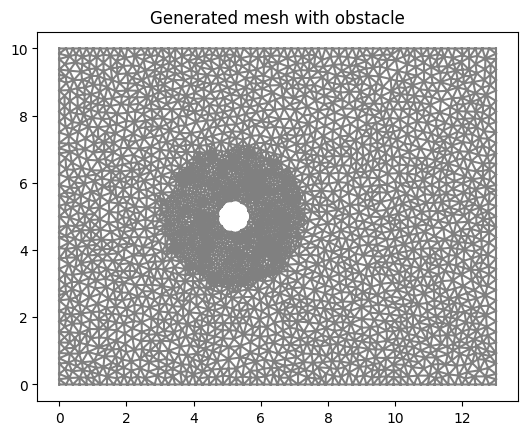

Dimensionless inflow values: 
 inflow density: 1.000, inflow momentum: 1.000, inflow energy: 0.500
Dimensional inflow values: 
 inflow density: 0.194, inflow momentum: 0.194, inflow energy: 87183717.089
Inflow velocity: Dimensionless: 1.0, Dimensional: 30000.0
time-step length: dt = 0.004964364956652093
Starting simulation...

Time t = 0.005
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_46130370363827ad3c3f12f0c847e8eb23924528

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    1
  Coefficients:              '[f_61]'
  Unique elements:           'Vector<2 x CG1(?,?)>'
  Unique sub elements:       'Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 2
INFO:FFC:  quadrature_degree: 2
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.131592 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-----------------------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_2d3231698cef1a1d2ef91dd25a6a6ed2eda0ad0f

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    1
  Coefficients:              '[f_64]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 2
INFO:FFC:  quadrature_degree: 2
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0738051 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:------------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_19cde2174555f448f7e879bdadcb97c0853064cb

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    2
  Coefficients:              '[f_58, f_61]'
  Unique elements:           'Vector<2 x CG1(?,?)>, CG1(?,?)'
  Unique sub elements:       'Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 3
INFO:FFC:  quadrature_degree: 3
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0380676 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_b6cb73de0c5e01fcd4c9457c0aa0346fbbab4880

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    2
  Coefficients:              '[f_58, f_61]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 7
INFO:FFC:  quadrature_degree: 7
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0318735 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_c6e1afca2496e5f01ee4769cb29da37dd8d806b8

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    3
  Coefficients:              '[f_58, f_61, f_64]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 5
INFO:FFC:  quadrature_degree: 5
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0292273 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:------------------

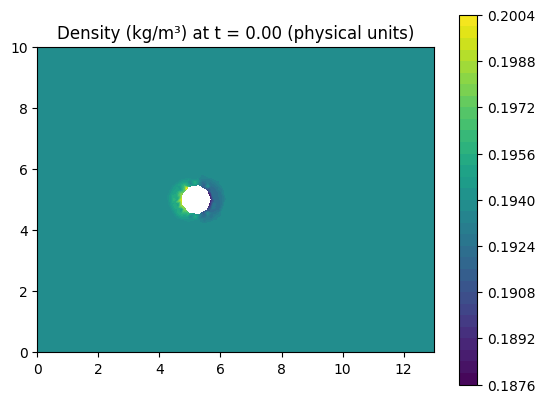

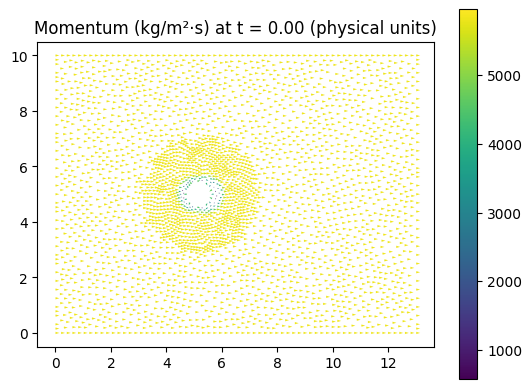

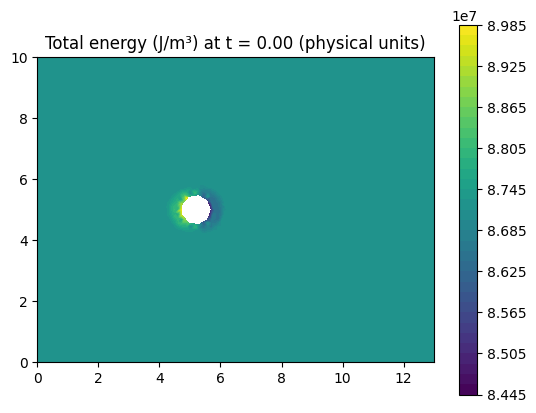

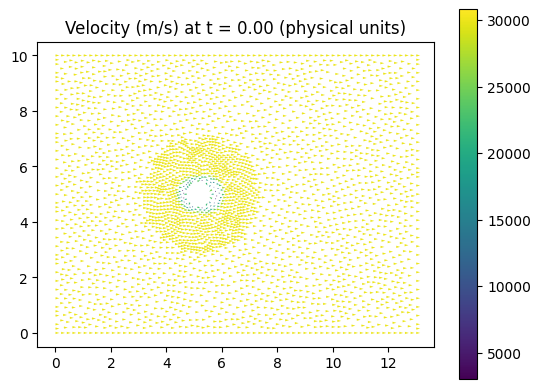

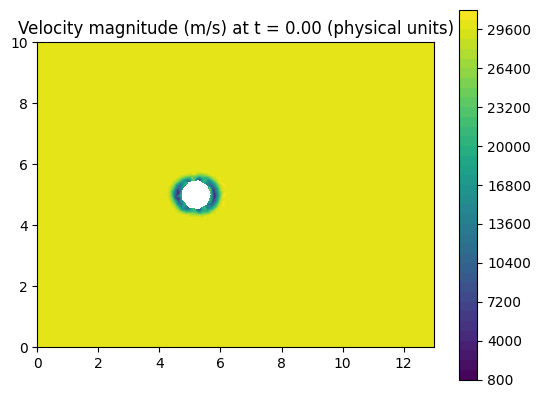

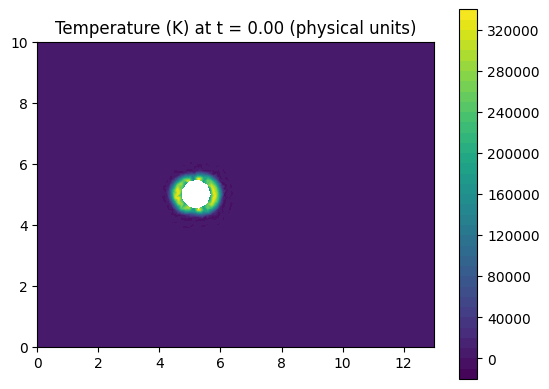

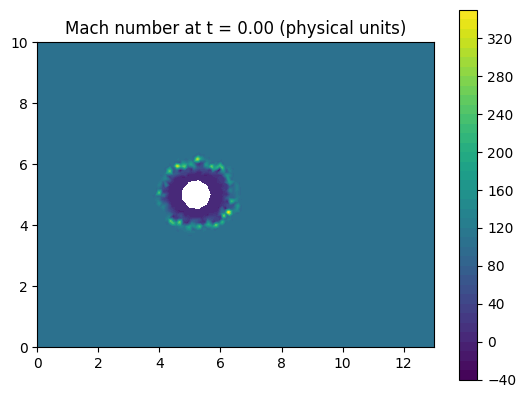

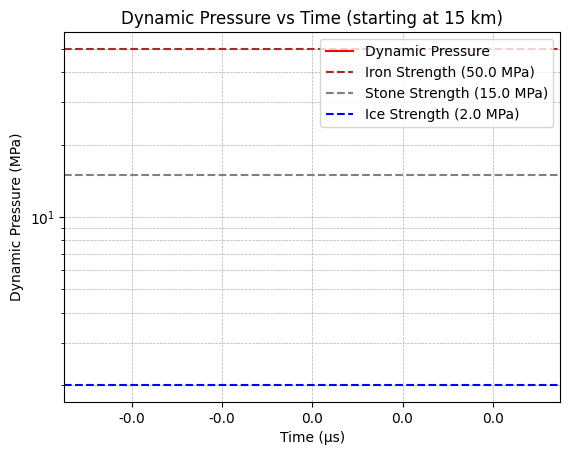

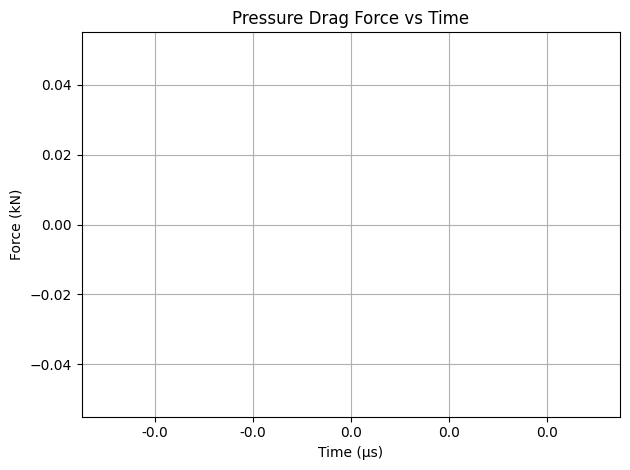


Time t = 0.402


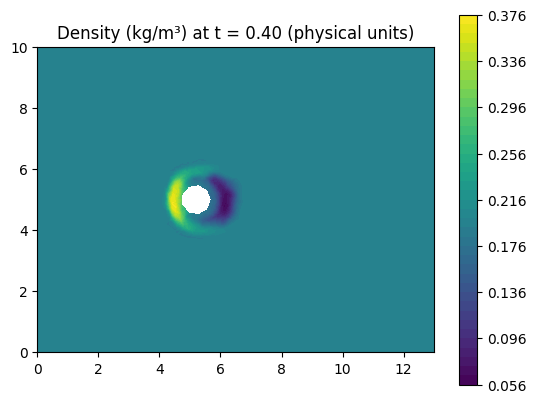

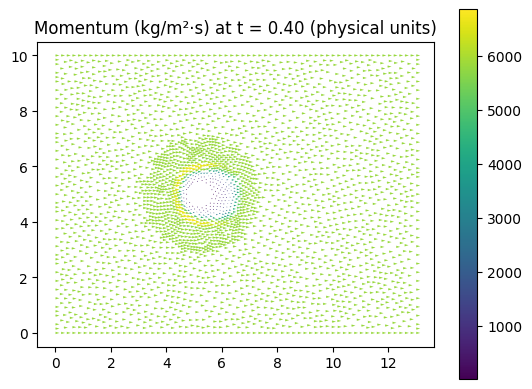

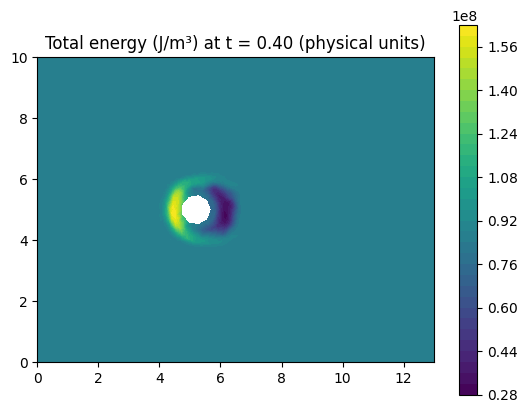

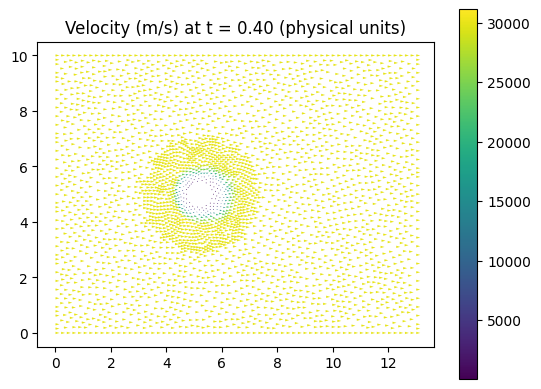

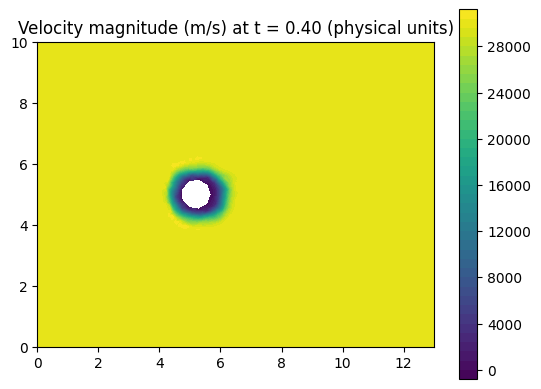

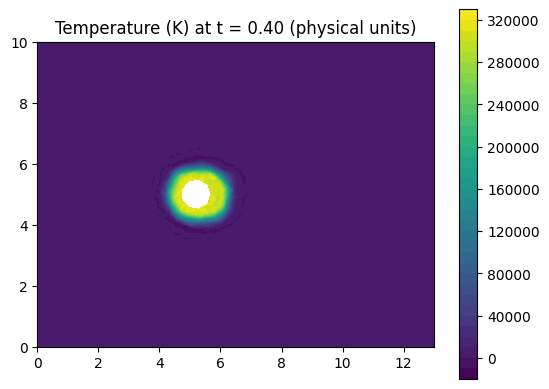

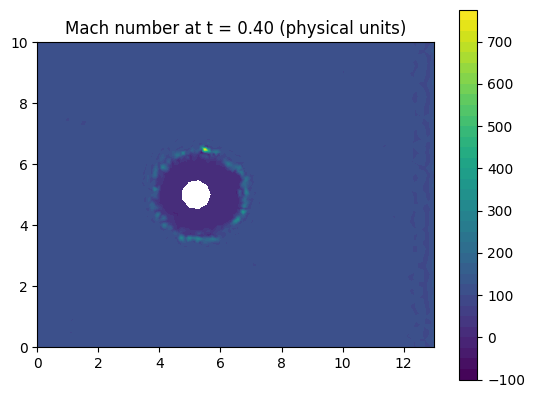

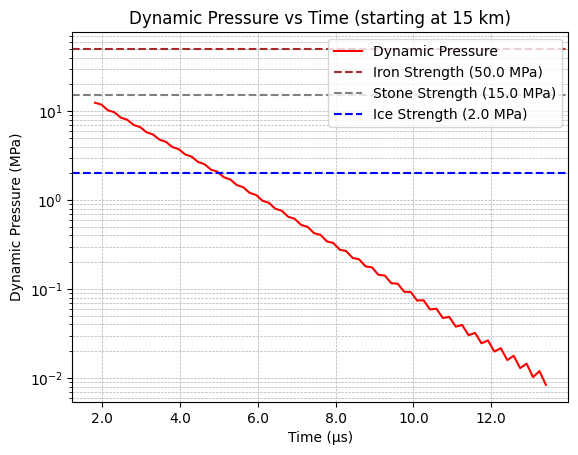

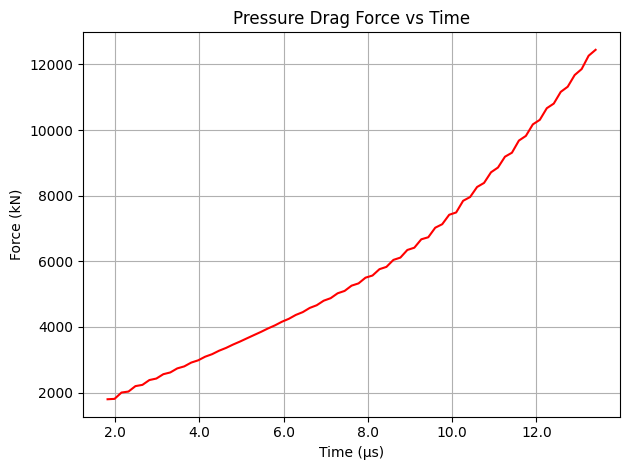


Time t = 0.804


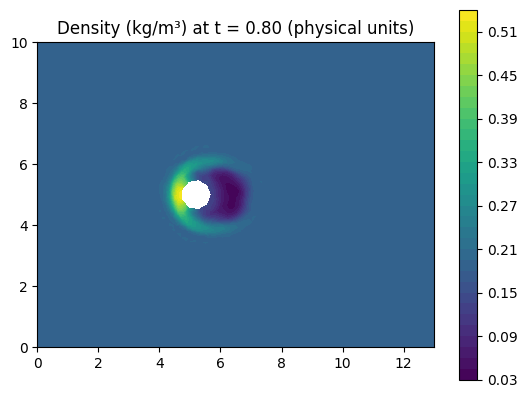

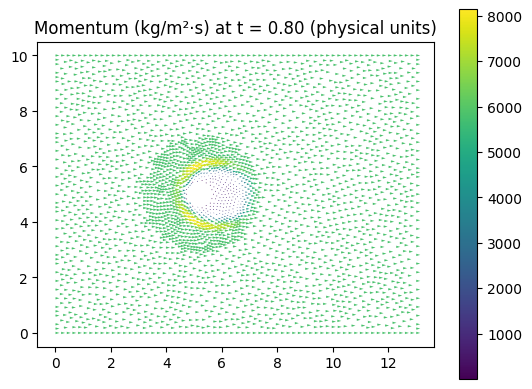

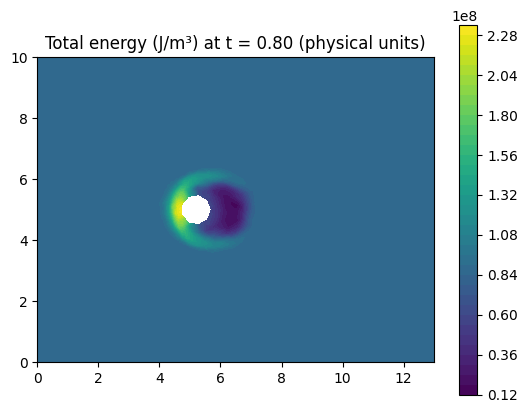

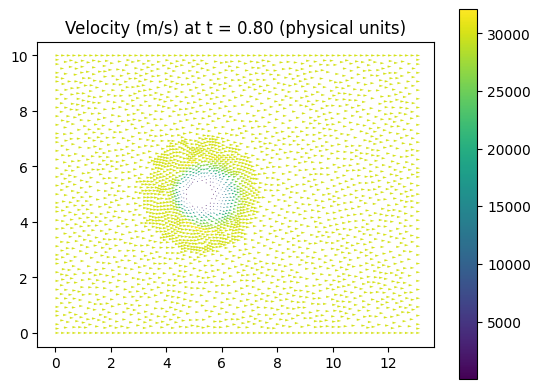

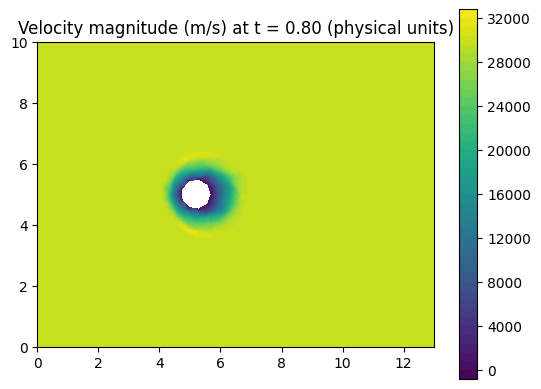

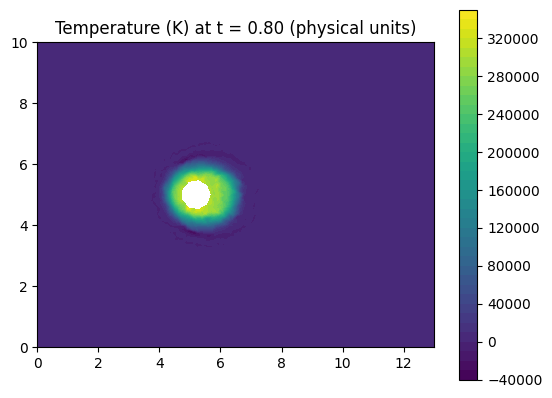

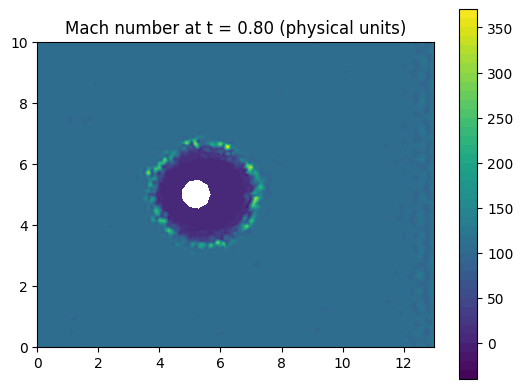

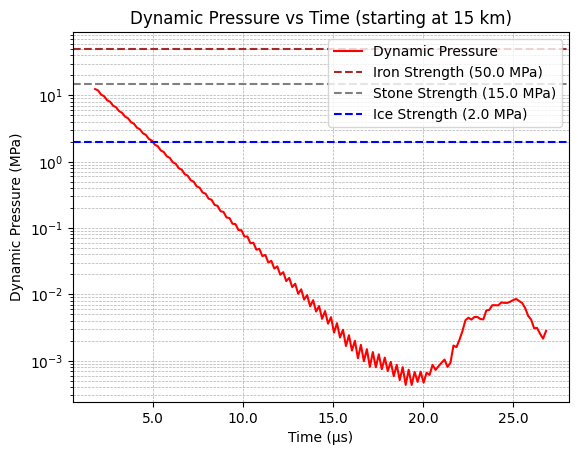

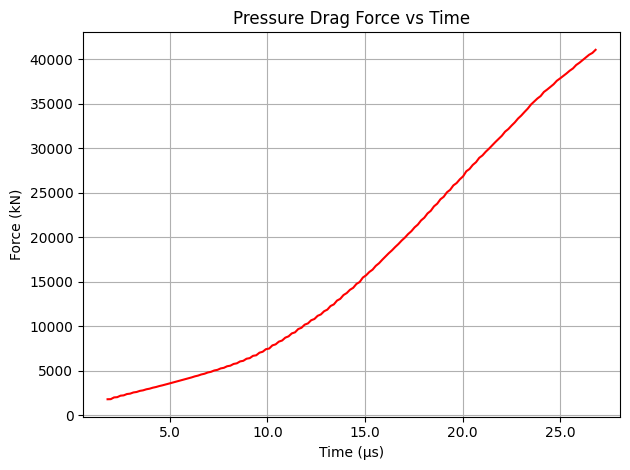


Time t = 1.201


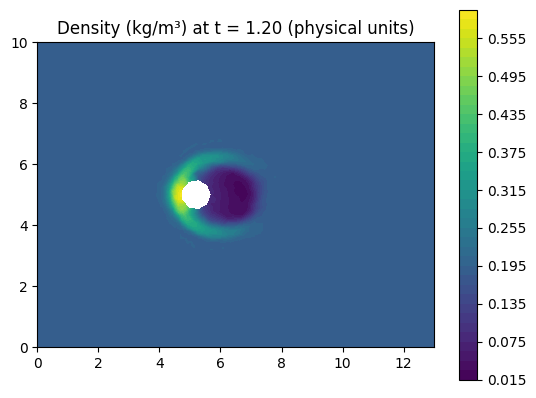

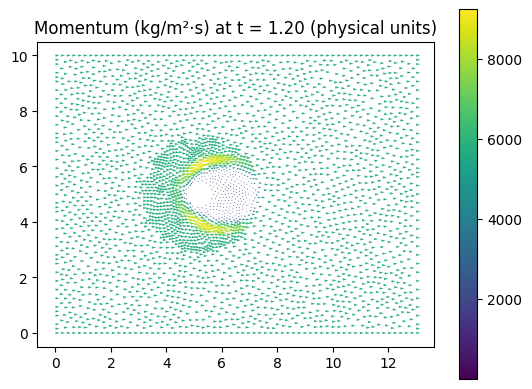

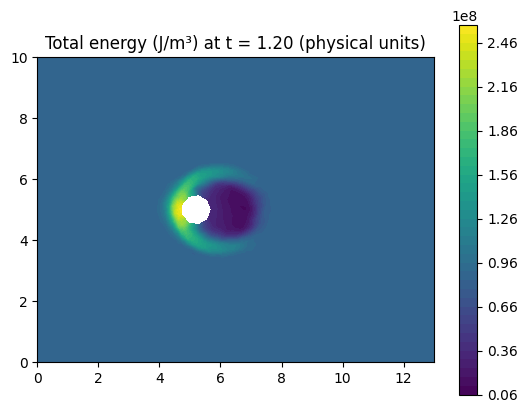

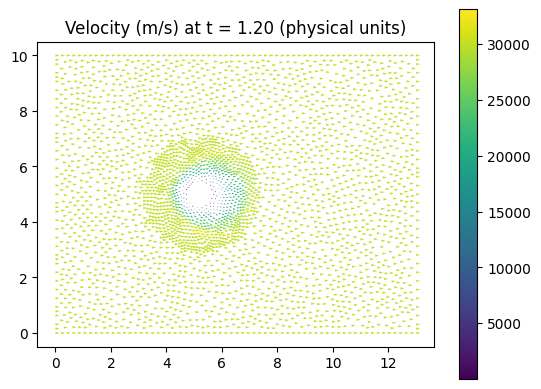

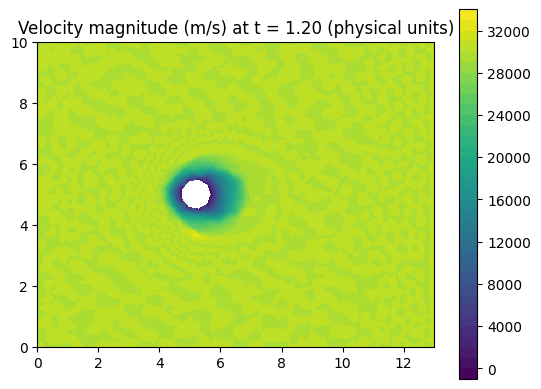

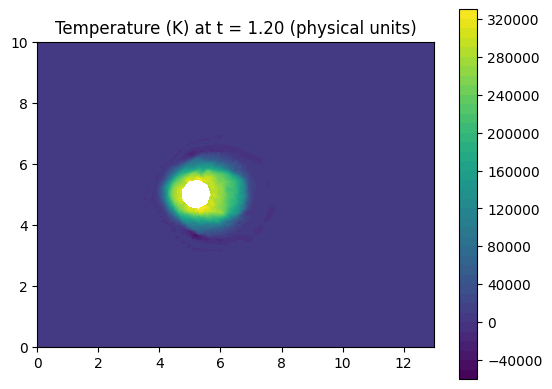

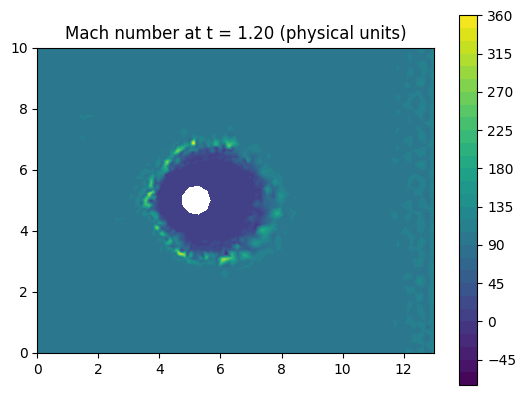

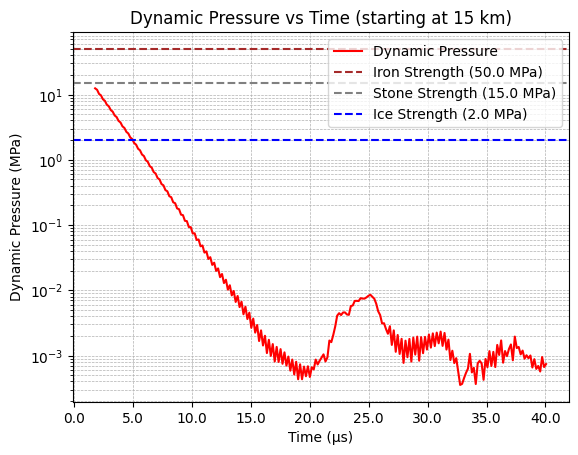

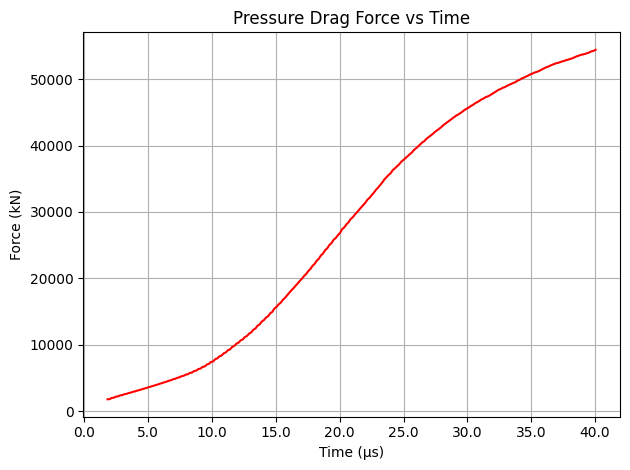


Time t = 1.603


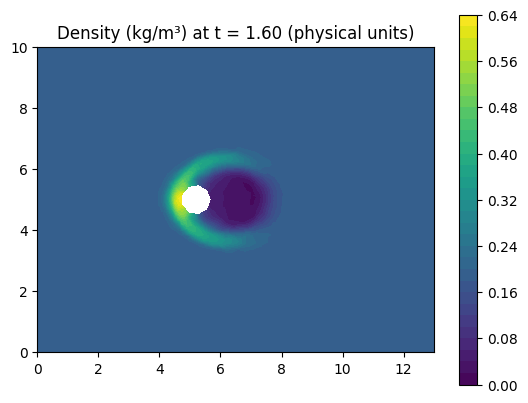

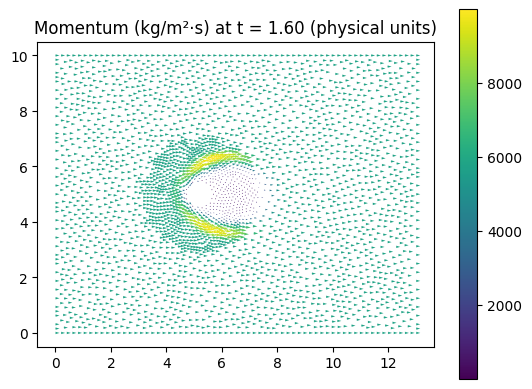

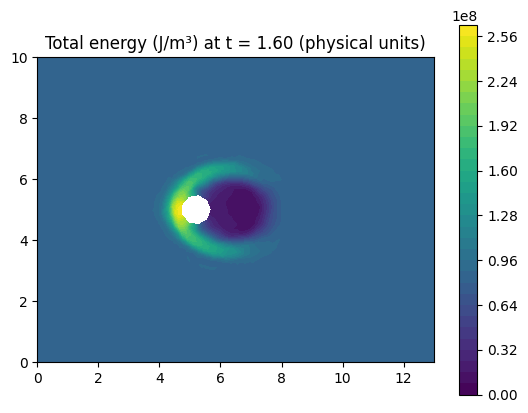

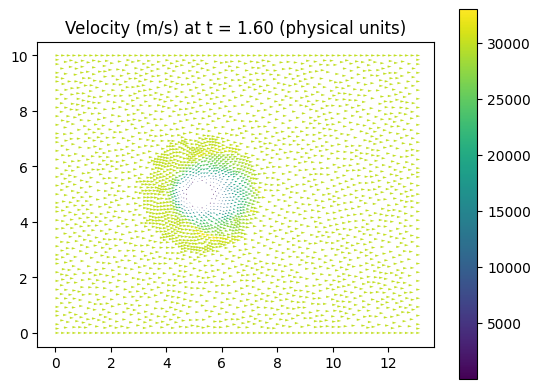

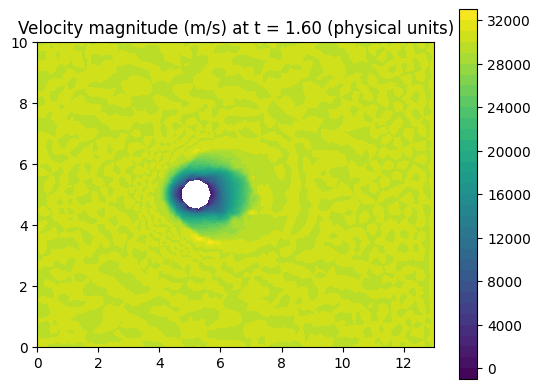

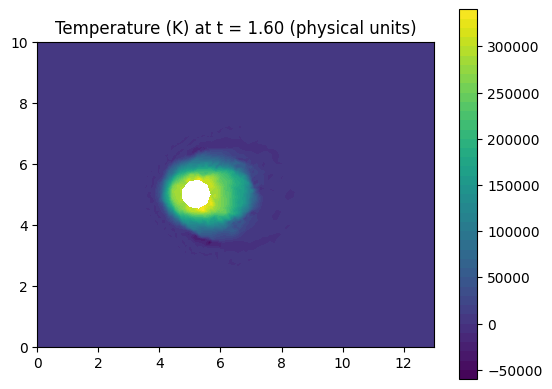

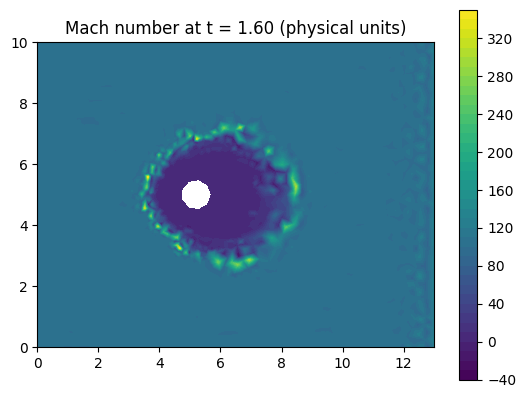

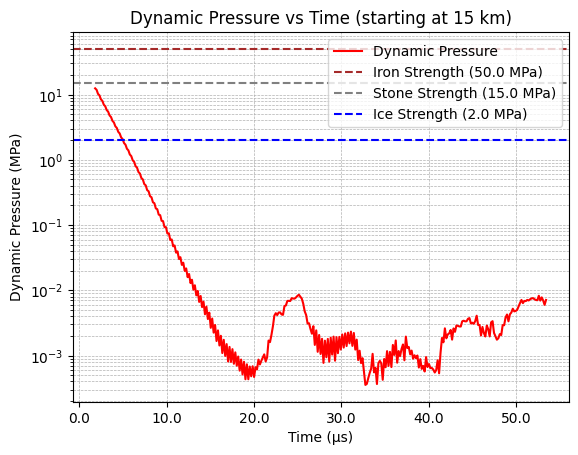

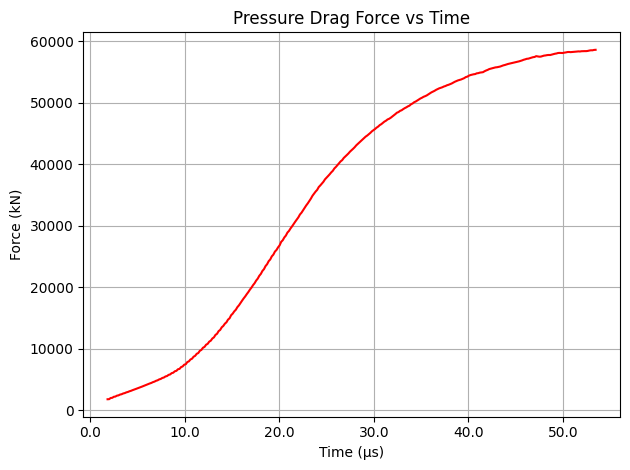


Time t = 2.001


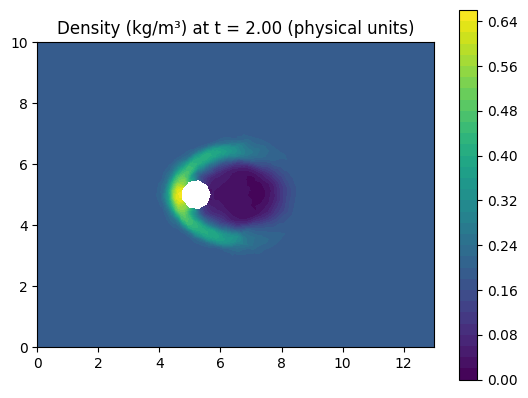

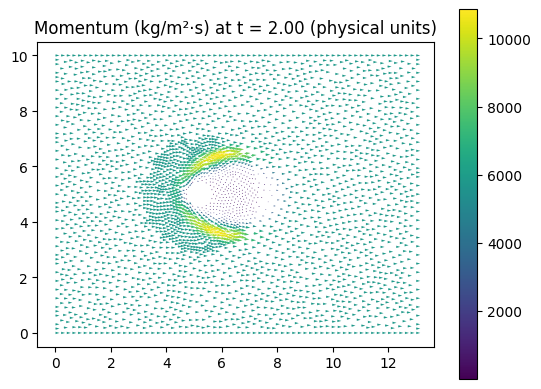

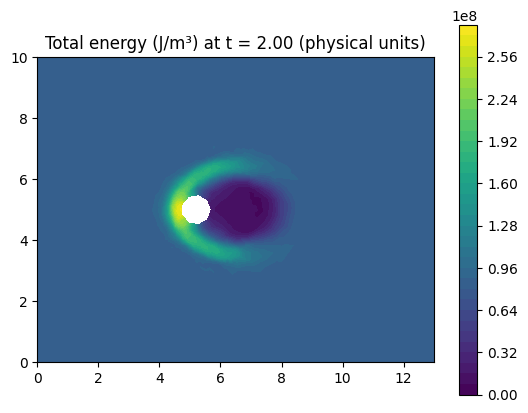

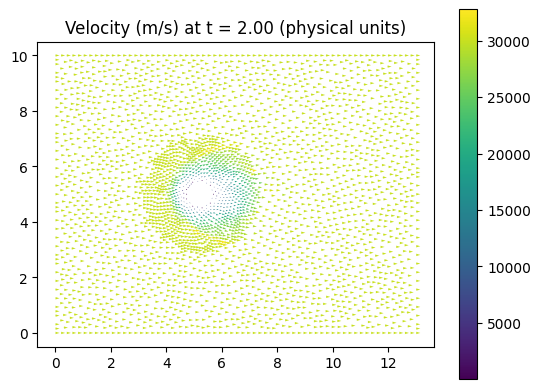

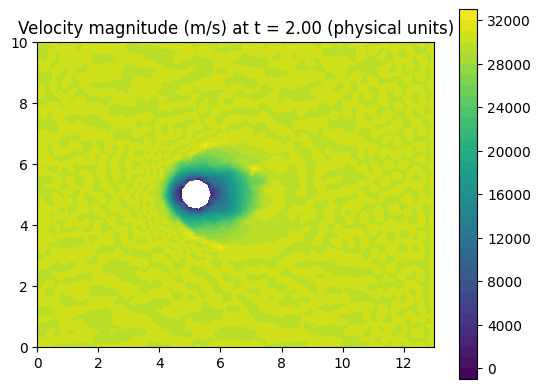

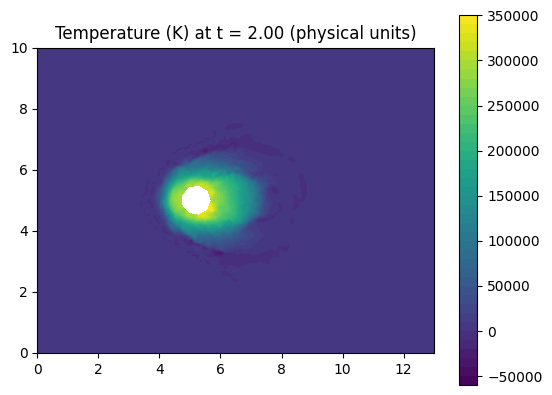

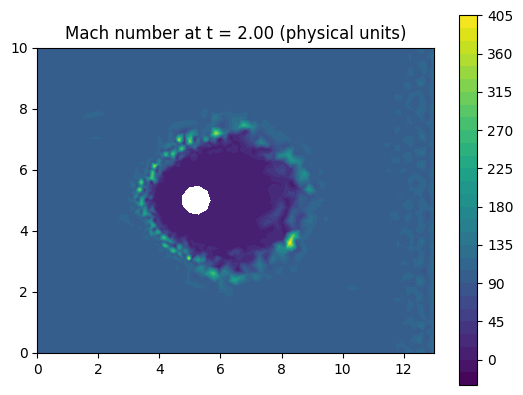

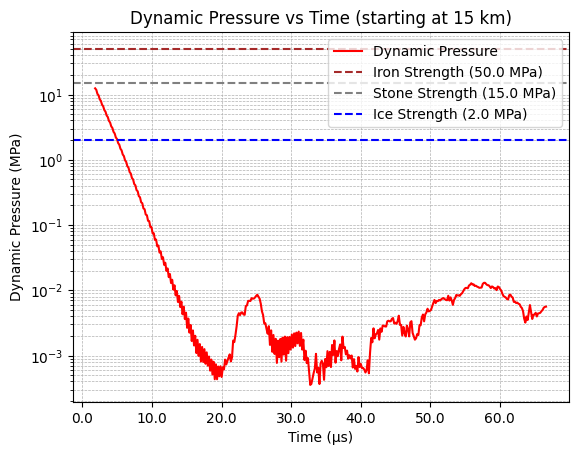

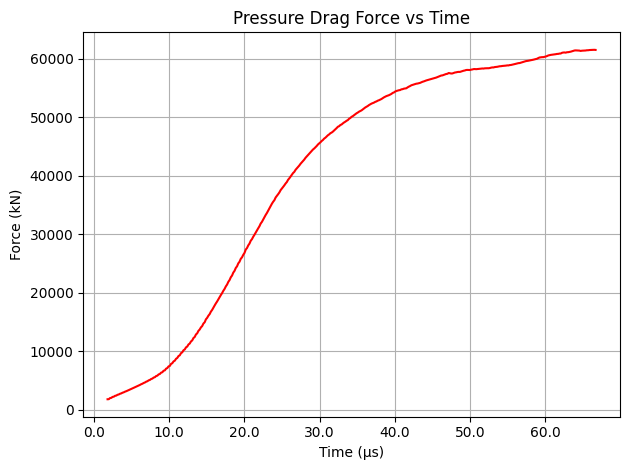

KeyboardInterrupt: 

In [16]:
#   Parameters
# material = 'iron'   # 'iron'  'ice'  'stone'
altitude = 20000.0      # meters
velocity_in = 19000.0   # m/s (reentry speed)
D_real = 18.0                   #characteristic length (meteor diameter (m))
D = D_real / D_real

L = 13*D_real /D_real                 # domain length dimensionless
H = 10*D_real / D_real                   # domain height dimensionless
T = 10.0                 # total simulation time (nondimensional)
resolution = 40
refine_levels = 1
refinement_radius = 4 * (D/2)
plot_mesh = True
plot_freq = 90
num_nnlin_iter = 7
gamma = 1.4

#     Get material data: keys: "density" [kg/m^3], "strength" [Pa], "name"
iron = get_material_properties("iron")
ice = get_material_properties("ice")
stone = get_material_properties("stone")
props = [iron, stone, ice]

#     Create geometry
mesh, boundaries, ds, rc, xc, yc = make_domain_and_boundaries(L=L, H=H, rc=D/2, resolution=resolution, refine_levels=refine_levels,refinement_radius = refinement_radius, plot_mesh=plot_mesh)

#     Compute dimensionless inflow
#     keys: Inflow: "rho", "u", "E", "p", "T", Real values: "rho_phys", "E_phys", "T_phys"
inflow = compute_dimensionless_inflow(altitude, velocity_in, gamma=gamma)

#     Finite element spaces
R, V, Q, trial_funcs, test_funcs = make_function_spaces(mesh)

#     Boundary conditions and inflow Constants

bcr, bcm, bcE, r_in, m_in, E_in = make_boundary_conditions(mesh, R, V, Q, ds, inflow, altitude, L, H)

#     Initial state and solver fields
r0, m0, E0, r1, m1, E1, dt, eps_cav, num_nnlin_iter, prec = initialize_solver_state(R, V, Q, mesh, inflow, num_nnlin_iter)

# Interpolate constant initial state
r0.interpolate(Constant(inflow["rho"]))
m0.interpolate(Constant((inflow["rho"] * inflow["u"], 0.0)))
E0.interpolate(Constant(inflow["E"]))

#   Define variational forms
ar, Lr, am, Lm, aE, LE = define_variational_forms(
    mesh, ds, R, V, Q,
    trial_funcs, test_funcs,
    r0, m0, E0, r1, m1, E1,
    dt, eps_cav,
    r_in, m_in, E_in,
    gamma
    )

#   Compute surface force expression (for drag)
psi_dir = (1.0, 0.0)

Force_pressure, normalization = compute_surface_force(
    mesh, psi_dir=psi_dir, ds=ds, p1=(gamma - 1.0) * (E1 - 0.5 * inner(m1, m1)/(r1 + eps_cav)),
    boundaries=boundaries, surface_id=5, rc=rc
    )

#   Compute maximum dynamic pressure on part of the front-facing boundary of the object
dynamic_pressure_front = compute_surface_dynamic_pressure(
    mesh=mesh, m1=m1, r1=r1, ds=ds, boundaries=boundaries,
    surface_id=5, front_normal=Constant((1.0, 0.0)), rc=rc,
    eps_cav=eps_cav, angle_threshold=0.7
    )

#   Export files
import os
os.makedirs("results-NS", exist_ok=True)
file_r = File("results-NS/r.pvd")
file_m = File("results-NS/m.pvd")
file_E = File("results-NS/E.pvd")
file_Mach = File("results-NS/Mach.pvd")

#    Run the simulation
run_simulation(
    T=T, dt=dt, num_nnlin_iter=num_nnlin_iter, gamma=gamma,
    ar=ar, Lr=Lr, am=am, Lm=Lm, aE=aE, LE=LE,
    r0=r0, m0=m0, E0=E0, r1=r1, m1=m1, E1=E1,
    bcr=bcr, bcm=bcm, bcE=bcE,
    Force_pressure=Force_pressure, normalization=normalization,
    dynamic_pressure_front=dynamic_pressure_front,
    file_r=file_r, file_m=file_m, file_E=file_E, file_Mach=file_Mach,
    R=R, V=V, Q=Q, eps_cav=eps_cav,
    mesh=mesh,
    altitude=altitude,
    velocity_in=velocity_in,
    rho_in=inflow["rho"],
    domain_scaling=D,
    props=props,
    inflow=inflow,
    start_sample_time=0.05,
    plot_freq=plot_freq,
    plot_callback=default_plot_callback
    )



Export for paraview:

In [ ]:
!tar -czvf results-NS.tar.gz results-NS
files.download('results-NS.tar.gz')

# **Discussion**

A stabilized finite element method was implemented in FEniCS to solve the Euler equations for compressible flow in 2D.